# House price predictor

## 1. Import important libraries

In [158]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)

## 2. Import data

In [159]:
df1 = pd.read_csv("D:\Akash\ML Project\project-1\Bengaluru_House_Data.csv")
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [160]:
df1.shape

(13320, 9)

# 3. Data Processing and cleaning

In [161]:
df1.groupby('area_type')['area_type'].agg('count')

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

In [162]:
## remove unwanted columns
df = df1.drop(['area_type','availability','society','balcony'],axis='columns')
df.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [163]:
# find null data
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [164]:
df.dropna(inplace=True)
df.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [165]:
df.shape

(13246, 5)

In [166]:
df['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [167]:
# seperate no. only 
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))
df.bhk.unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18], dtype=int64)

In [168]:
df.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [169]:
# to check more errors like ths in this row
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

df[~df['total_sqft'].apply(is_float)].head(10)

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4


In [170]:
def convert_sqrt_to_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None

df.total_sqft = df.total_sqft.apply(convert_sqrt_to_num)
df = df[df.total_sqft.notnull()]
df.loc[30]

location      Yelahanka
size              4 BHK
total_sqft       2475.0
bath                4.0
price             186.0
bhk                   4
Name: 30, dtype: object

In [171]:
df['price_per_sqft'] = (df['price']/df['total_sqft'])*100000
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [172]:
## convert word data into no. code 
df.location = df.location.apply(lambda x: x.strip())
location_stats = df['location'].value_counts(ascending=False)
location_stats

Whitefield               533
Sarjapur  Road           392
Electronic City          304
Kanakpura Road           264
Thanisandra              235
                        ... 
Rajanna Layout             1
Raja Rajashweri Nagar      1
kanakapura main road       1
NR Colony                  1
Chowdeshwari Layout        1
Name: location, Length: 1287, dtype: int64

In [173]:
# we classify all locations having very less occurence as others
df.location = df.location.apply(lambda x: 'others' if x in location_stats[location_stats<=10] else x)
len(df.location.unique())

241

In [174]:
df.head(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
5,Whitefield,2 BHK,1170.0,2.0,38.00,2,3247.863248
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4,7467.057101
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4,18181.818182
8,Marathahalli,3 BHK,1310.0,3.0,63.25,3,4828.244275
9,others,6 Bedroom,1020.0,6.0,370.00,6,36274.509804


# we have to remove all the misleading datapoints 

In [175]:
df[df.total_sqft/df.bhk < 300].head() 

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,others,6 Bedroom,1020.0,6.0,370.0,6,36274.509804
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333.333333
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.980810
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6296.296296
70,others,3 Bedroom,500.0,3.0,100.0,3,20000.000000


In [176]:
df.shape

(13200, 7)

In [177]:
df = df[~(df.total_sqft/df.bhk < 300)]
df.shape

(12456, 7)

In [178]:
df.price_per_sqft.describe()

count     12456.000000
mean       6308.502826
std        4168.127339
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [179]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out,reduced_df],ignore_index=True)
    return df_out

df = remove_pps_outliers(df)
df.shape

(10242, 7)

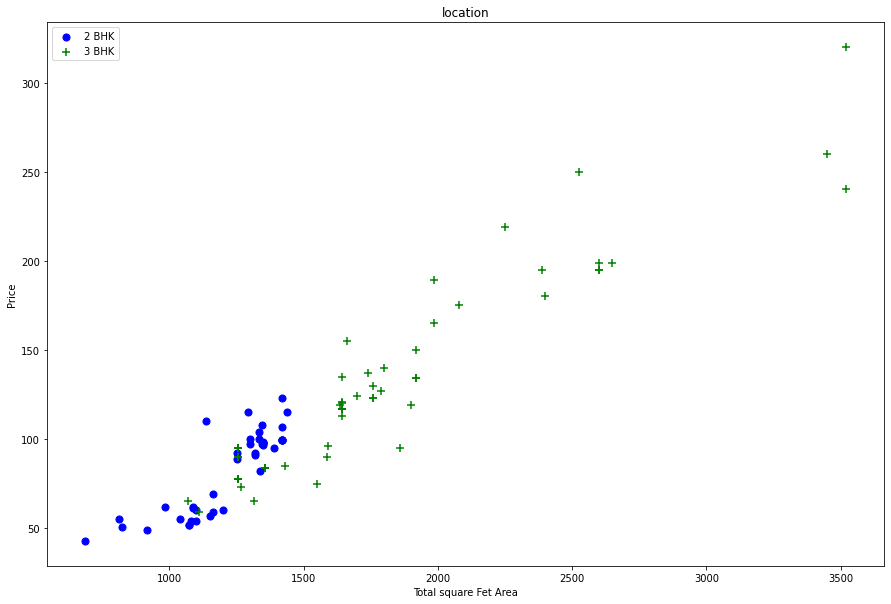

In [180]:
def plot_scatter_chart(df , location):
    bhk2 = df[(df.location == location) & (df.bhk == 2)] 
    bhk3 = df[(df.location == location) & (df.bhk == 3)] 
    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.total_sqft, bhk2.price, color = 'blue', label = '2 BHK' ,s=50)
    plt.scatter(bhk3.total_sqft, bhk3.price, marker = '+' ,color = 'green', label = '3 BHK' ,s=50)
    plt.xlabel("Total square Fet Area")
    plt.ylabel("Price")
    plt.title('location')
    plt.legend()

plot_scatter_chart(df,"Hebbal")

### here many 2 bhk flat have higher value than 3 bhk , we have to remove that 

In [181]:
df.bhk.describe()

count    10242.000000
mean         2.572642
std          0.897242
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         16.000000
Name: bhk, dtype: float64

In [182]:
def remove_bhk_outliers(df):
    excludes_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                excludes_indices = np.append(excludes_indices,bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(excludes_indices , axis='index')

df = remove_bhk_outliers(df)
df.shape

(7317, 7)

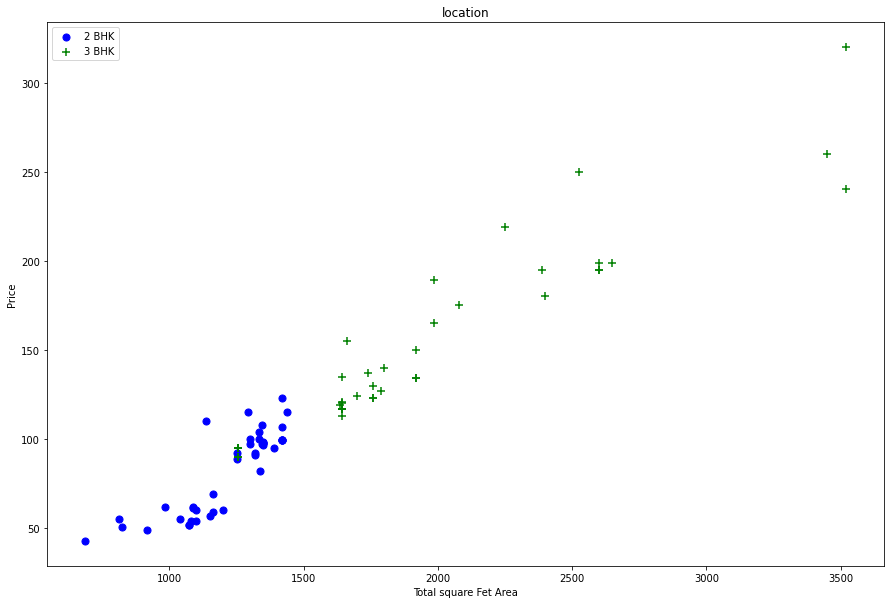

In [183]:
plot_scatter_chart(df,"Hebbal")

In [184]:
# Now we have to fix bathroom columns
df = df[df.bath<df.bhk+2]
df.shape

(7239, 7)

In [185]:
df = df.drop(['size','price_per_sqft'],axis='columns')
df.head(3)

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3


In [186]:
# Use One Hot Encoding For Location
dummies = pd.get_dummies(df.location)
df = pd.concat([df,dummies],axis='columns')
df.head()

,location,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,others
0,1st Block Jayanagar,2850.0,4.0,428.0,4,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1st Block Jayanagar,1630.0,3.0,194.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1st Block Jayanagar,1875.0,2.0,235.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1st Block Jayanagar,1200.0,2.0,130.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1st Block Jayanagar,1235.0,2.0,148.0,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [187]:
df = df.drop('location',axis='columns')
df.shape

(7239, 245)

# 4. Model Building and Training the data

In [188]:
x = df.drop('price',axis='columns')
y = df.price

In [189]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=10)

In [190]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor

## hyper Parameter Tuning using GridSearchCV

In [191]:

model_parameter = {
    'linear_regression': {
        'model' : LinearRegression(),
        'params': {
            'normalize' : [True , False]
        }
    },
    'lasso':{
        'model': Lasso(),
        'params': {
            'alpha' : [1,2],
            'selection' : ['random' , 'cyclic']
        }
    },
    'decision_tree':{
        'model': DecisionTreeRegressor(),
        'params': {
            'criterion' : ['mse','friedman_mse'],
            'splitter' : ['best','random']
        }
    }

}

In [192]:
scores = []
cv = ShuffleSplit(n_splits=5 , test_size=0.2 , random_state=0)
for model_name , mp in model_parameter.items():
    clf = GridSearchCV(mp['model'] ,mp['params'], cv=cv, return_train_score=False)
    clf.fit(x,y)
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_paramater': clf.best_params_
    })

dfr = pd.DataFrame(scores,columns=['model','best_score','best_paramater'])
dfr

,model,best_score,best_paramater
0,linear_regression,0.847888,{'normalize': False}
1,lasso,0.738732,"{'alpha': 1, 'selection': 'cyclic'}"
2,decision_tree,0.782682,"{'criterion': 'friedman_mse', 'splitter': 'ran..."


## Here we can say that our linear regression model is the best model

In [193]:
final_model = LinearRegression()
final_model.fit(x_train , y_train)

LinearRegression()

# 5. Predict the price

In [194]:
x.columns

Index(['total_sqft', 'bath', 'bhk', '1st Block Jayanagar',
       '1st Phase JP Nagar', '2nd Phase Judicial Layout',
       '2nd Stage Nagarbhavi', '5th Block Hbr Layout', '5th Phase JP Nagar',
       '6th Phase JP Nagar',
       ...
       'Vishveshwarya Layout', 'Vishwapriya Layout', 'Vittasandra',
       'Whitefield', 'Yelachenahalli', 'Yelahanka', 'Yelahanka New Town',
       'Yelenahalli', 'Yeshwanthpur', 'others'],
      dtype='object', length=244)

In [195]:
np.where(x.columns == '2nd Phase Judicial Layout')

(array([5], dtype=int64),)

In [196]:
np.where(x.columns == '2nd Phase Judicial Layout')[0][0]

5

In [197]:
def predict_price(location , sqft , bath , bhk):
    loc_index = np.where(x.columns == location)[0][0]

    c = np.zeros(len(x.columns))
    c[0] = sqft
    c[1] = bath
    c[2] = bhk
    if loc_index >= 0:
        c[loc_index] = 1

    return final_model.predict([c])[0]

In [198]:
predict_price('1st Phase JP Nagar',1000,2,2)

83.86570258312597

In [199]:
predict_price('1st Phase JP Nagar',1000, 3, 3)

86.08062284987275

In [200]:
predict_price('Indira Nagar',1000, 2, 2)

193.31197733177328

In [201]:
predict_price('Indira Nagar',1000, 3, 3)

195.52689759852012

# Export the tested model to a pickle file

In [203]:
import pickle
with open('banglore_home_prices_model.pickle','wb') as f:
    pickle.dump(final_model,f)